In [47]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
game_ids = set()

In [17]:
url = 'https://steamspy.com/api.php?request=all'

r = requests.get(url)
data = r.json()
for id in data.keys():
    game_ids.add(id)


In [26]:
len(game_ids)

1000

In [29]:
base = 'https://store.steampowered.com/appreviews/'
after = '?json=1&num_per_page=100&cursor=*'

dataset = []


for game_id in game_ids:
    url = base + game_id + after
    r = requests.get(url)
    data = r.json()
    reviews = data.get("reviews", [])

    for review in reviews:
        author = review.get("author", {})
        num_review = int(author.get("num_reviews"))
        if num_review < 2:
            continue

        dataset.append(
            {"user_id" : author.get("steamid"),
             "game_id" : game_id,
             "voted_up": review.get("voted_up"),
             "playtime_at_review" : author.get("playtime_at_review")}
        )


In [30]:
len(dataset)

50177

In [31]:
df = pd.DataFrame(dataset)
df.to_csv("steam_reviews.csv", index=False)

In [32]:
df.head()

,user_id,game_id,voted_up,playtime_at_review
0,76561198051600732,500,True,323.0
1,76561199593266214,500,True,12811.0
2,76561198733334274,500,True,2070.0
3,76561198318574261,500,True,256.0
4,76561198018170309,500,False,247.0


In [62]:
user_counts = df["user_id"].value_counts()
valid_users = user_counts[user_counts >= 2].index

df_filtered = df[df["user_id"].isin(valid_users)]

game_counts = df_filtered["game_id"].value_counts()
valid_games = game_counts[game_counts >= 2].index

df_filtered = df_filtered[df_filtered["game_id"].isin(valid_games)]

df_filtered

,user_id,game_id,voted_up,playtime_at_review
3,76561198318574261,500,True,256.0
6,76561198783133953,500,True,88.0
9,76561199198666356,500,True,10.0
11,76561198137902025,500,True,307.0
12,76561198023590229,500,True,60.0
...,...,...,...,...
50166,76561198043388752,257510,True,1066.0
50167,76561198329474499,257510,True,2108.0
50171,76561198234546328,236870,False,3764.0
50172,76561197963366821,236870,False,1927.0


In [63]:
df_filtered["voted_up"] = df_filtered["voted_up"].map(lambda x: 1 if x is True else 0)
df_filtered

,user_id,game_id,voted_up,playtime_at_review
3,76561198318574261,500,1,256.0
6,76561198783133953,500,1,88.0
9,76561199198666356,500,1,10.0
11,76561198137902025,500,1,307.0
12,76561198023590229,500,1,60.0
...,...,...,...,...
50166,76561198043388752,257510,1,1066.0
50167,76561198329474499,257510,1,2108.0
50171,76561198234546328,236870,0,3764.0
50172,76561197963366821,236870,0,1927.0


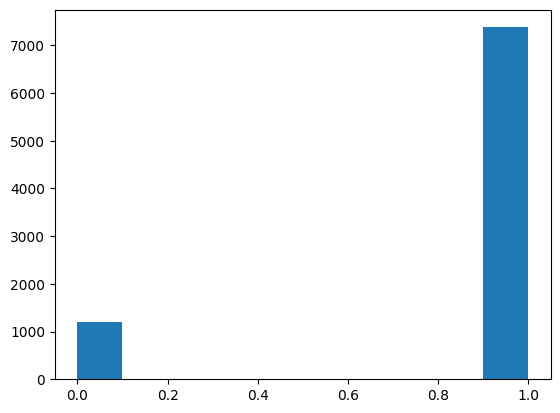

In [64]:
plt.hist(df_filtered['voted_up'])
plt.show()

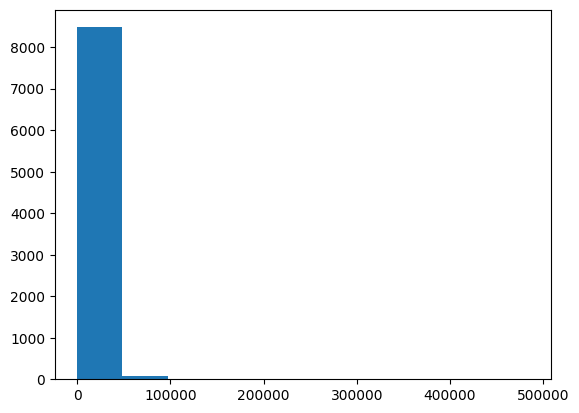

In [68]:
plt.hist(df_filtered['playtime_at_review'])
plt.show()

In [66]:
df_filtered.to_csv("steam_reviews.csv", index=False)